# EC523 Project — Speech Denoising

Tamerlan Baimurat, Punnisa Amornsirikul, Jiaxing Wang, Michael Lwe

{baimurat, punnisa, jiaxingw, mlwe}@bu.edu

Spring 2026


**Dataset:** 23,075 training + 824 test paired clean/noisy utterances (16 kHz, mono).
All audio has been preprocessed to complex STFT tensors (`complex64`, shape `[257, T]`) and served via a public HTTP endpoint: https://ec523.tamerlanbaimurat.com.

**Goal:** Build and train a neural network that takes a noisy STFT spectrogram as input and produces a denoised (clean) spectrogram as output.

# 1. Setup

This section loads all required libaries for our project.

In [ ]:
!pip install flash-linear-attention
!pip install torch-pesq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.3/595.3 kB 56.7 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
from __future__ import print_function
import io
import json
import os
import random
import threading
import time
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import requests
from requests.adapters import HTTPAdapter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from fla.layers import DeltaNet

from torch_pesq import PesqLoss

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set to {seed}")

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Random seed set to 42
Device: cuda


# 2. Retrieving Data

The following Python script retrives the training and testing dataset from our HTML endpoint, https://ec523.tamerlanbaimurat.com.

In [ ]:
BASE_URL = "https://ec523.tamerlanbaimurat.com"
MAX_RETRIES = 5

def public_url(key: str) -> str:
    return f"{BASE_URL}/{quote(key.lstrip('/'), safe='/')}"

_local = threading.local()

def _session() -> requests.Session:
    if not hasattr(_local, "s"):
        s = requests.Session()
        adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64)
        s.mount("https://", adapter)
        _local.s = s
    return _local.s

def fetch_bytes(key: str, timeout: int = 60) -> bytes:
    for attempt in range(MAX_RETRIES):
        try:
            r = _session().get(public_url(key), timeout=timeout)
            if r.status_code == 503:
                raise requests.exceptions.ConnectionError("503")
            r.raise_for_status()
            return r.content
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout,
                requests.exceptions.HTTPError):
            if attempt == MAX_RETRIES - 1:
                raise
            time.sleep(2 ** attempt + random.random())
    return b""

def fetch_manifest(split: str) -> list[dict]:
    key = f"{PREFIX}/manifests/{split}.jsonl"
    text = fetch_bytes(key).decode()
    return [json.loads(line) for line in text.splitlines() if line.strip()]


class AdaptivePool:
    """AIMD concurrency: starts fast, backs off on 503, recovers quickly."""

    def __init__(self, initial=32, minimum=4, maximum=64, grow_every=20):
        self._sem_value = initial
        self._sem = threading.Semaphore(initial)
        self._lock = threading.Lock()
        self._min = minimum
        self._max = maximum
        self._grow_every = grow_every
        self.successes = 0
        self.errors = 0

    @property
    def window(self):
        return self._sem_value

    def acquire(self):
        self._sem.acquire()

    def release_success(self):
        with self._lock:
            self.successes += 1
            if self.successes % self._grow_every == 0 and self._sem_value < self._max:
                self._sem_value += 1
                self._sem.release()
                return
        self._sem.release()

    def release_error(self):
        with self._lock:
            self.errors += 1
            new = max(self._sem_value // 2, self._min)
            while self._sem_value > new:
                self._sem.acquire(blocking=False) or None
                self._sem_value -= 1
        self._sem.release()


class STFTDataset(Dataset):
    """Fetches clean/noisy STFT pairs from HTTP, with in-memory caching."""

    def __init__(self, records: list[dict], split: str):
        self.records = records
        self.split = split
        self._cache: dict[int, tuple[torch.Tensor, torch.Tensor]] = {}

    @classmethod
    def from_manifest(cls, split: str) -> "STFTDataset":
        records = fetch_manifest(split)
        print(f"[{split}] manifest loaded: {len(records)} pairs")
        return cls(records, split)

    def prefetch_all(self):
        """Download every pair into RAM with adaptive concurrency."""
        from concurrent.futures import ThreadPoolExecutor, as_completed

        to_fetch = [i for i in range(len(self.records)) if i not in self._cache]
        if not to_fetch:
            print(f"[{self.split}] all {len(self.records)} pairs already cached")
            return

        pool = AdaptivePool(initial=32, minimum=4, maximum=128)

        def _download(idx):
            pool.acquire()
            try:
                rec = self.records[idx]
                noisy_bytes = fetch_bytes(rec["noisy_stft_key"])
                clean_bytes = fetch_bytes(rec["clean_stft_key"])
                noisy = torch.load(io.BytesIO(noisy_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                clean = torch.load(io.BytesIO(clean_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                pool.release_success()
                return idx, noisy, clean
            except Exception:
                pool.release_error()
                raise

        print(f"[{self.split}] prefetching {len(to_fetch)} pairs "
              f"(adaptive window: {pool.window}→{pool._max}) …")
        t0 = time.perf_counter()
        done, errors = 0, 0

        # Use a large thread pool; AdaptivePool's semaphore controls actual concurrency
        with ThreadPoolExecutor(max_workers=64) as ex:
            futures = {ex.submit(_download, i): i for i in to_fetch}
            for fut in as_completed(futures):
                try:
                    idx, noisy, clean = fut.result()
                    self._cache[idx] = (noisy, clean)
                    done += 1
                except Exception as e:
                    errors += 1
                    if errors <= 3:
                        print(f"  ERROR idx={futures[fut]}: {e}")
                total = done + errors
                if total % 500 == 0 or total == len(to_fetch):
                    elapsed = time.perf_counter() - t0
                    print(f"  {total}/{len(to_fetch)}  {elapsed:.0f}s  "
                          f"{done/max(elapsed,1):.0f} pairs/s  "
                          f"window={pool.window}  errors={errors}")
        elapsed = time.perf_counter() - t0
        print(f"[{self.split}] prefetch done: {done} OK, {errors} errors, "
              f"{elapsed:.0f}s")

        # Sequential retry for any failures
        remaining = [i for i in to_fetch if i not in self._cache]
        if remaining:
            print(f"[{self.split}] retrying {len(remaining)} failures …")
            for idx in remaining:
                try:
                    _, noisy, clean = _download(idx)
                    self._cache[idx] = (noisy, clean)
                except Exception as e:
                    print(f"  SKIP idx={idx}: {e}")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        rec = self.records[idx]

        if idx in self._cache:
            noisy, clean = self._cache[idx]
        else:
            noisy = torch.load(io.BytesIO(fetch_bytes(rec["noisy_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            clean = torch.load(io.BytesIO(fetch_bytes(rec["clean_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            self._cache[idx] = (noisy, clean)

        return {
            "pair_id":     rec["pair_id"],
            "split":       self.split,
            "sample_rate": int(rec["sample_rate"]),
            "noisy":       noisy,          # complex64 [257, T]
            "clean":       clean,          # complex64 [257, T]
            "length":      noisy.shape[-1],
        }

In [ ]:
# PREFIX = "ec523jiaxing"
PREFIX = "ec523project"
train_ds = STFTDataset.from_manifest("train")


# Download all data into RAM (~30.5 GB for 23K pairs).
# This takes 500 seconds to fetch
train_ds.prefetch_all()


[train] manifest loaded: 23075 pairs
[train] prefetching 23075 pairs (adaptive window: 32→128) …
  500/23075  15s  32 pairs/s  window=57  errors=0
  1000/23075  29s  35 pairs/s  window=82  errors=0
  1500/23075  43s  35 pairs/s  window=107  errors=0
  2000/23075  57s  35 pairs/s  window=128  errors=0
  2500/23075  72s  35 pairs/s  window=128  errors=0
  3000/23075  86s  35 pairs/s  window=128  errors=0
  3500/23075  101s  35 pairs/s  window=128  errors=0
  4000/23075  115s  35 pairs/s  window=128  errors=0
  4500/23075  129s  35 pairs/s  window=128  errors=0
  5000/23075  143s  35 pairs/s  window=128  errors=0
  5500/23075  157s  35 pairs/s  window=128  errors=0
  6000/23075  172s  35 pairs/s  window=128  errors=0
  6500/23075  187s  35 pairs/s  window=128  errors=0
  7000/23075  201s  35 pairs/s  window=128  errors=0
  7500/23075  215s  35 pairs/s  window=128  errors=0
  8000/23075  228s  35 pairs/s  window=128  errors=0
  8500/23075  242s  35 pairs/s  window=128  errors=0
  9000/2307

In [ ]:
PREFIX = "ec523project"
# PREFIX = "ec523jiaxing"
test_ds  = STFTDataset.from_manifest("test")
test_ds.prefetch_all()

[test] manifest loaded: 824 pairs
[test] prefetching 824 pairs (adaptive window: 32→128) …
  500/824  13s  38 pairs/s  window=57  errors=0
  824/824  23s  36 pairs/s  window=73  errors=0
[test] prefetch done: 824 OK, 0 errors, 23s


# 3. Data Helpers & DataLoaders

Utilities for converting complex STFT to magnitude/phase, collating variable-length batches, and creating DataLoaders.

In [ ]:
def stft_to_mag_phase(stft_complex):
    mag = stft_complex.abs()
    phase = stft_complex.angle()
    return mag, phase

In [ ]:
TIME_BUCKETS = [100, 200, 300, 400, 500, 600, 800, 1000, 1200, 1600]

def _bucket_pad(t: int) -> int:
    """Round up to the nearest bucket size so Triton sees fewer unique shapes."""
    for b in TIME_BUCKETS:
        if t <= b:
            return b
    return ((t + 63) // 64) * 64

def collate_magnitude(batch):
    """
    Custom collate that converts complex STFTs to log-magnitude tensors
    and pads to a fixed bucket size (reduces Triton recompilations).

    Returns dict with keys:
        noisy_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        clean_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        noisy_phase: [B, 257, T_bucket]     phase (for reconstruction)
        lengths:     [B]                     original T per sample
        pair_ids:    list[str]
    """
    max_t = max(item["noisy"].shape[-1] for item in batch)
    pad_to = _bucket_pad(max_t)

    noisy_mags, clean_mags, noisy_phases, lengths, pair_ids = [], [], [], [], []

    for item in batch:
        n_mag, n_phase = stft_to_mag_phase(item["noisy"])
        c_mag, _       = stft_to_mag_phase(item["clean"])

        pad_t = pad_to - n_mag.shape[-1]
        n_mag   = F.pad(n_mag, (0, pad_t))
        c_mag   = F.pad(c_mag, (0, pad_t))
        n_phase = F.pad(n_phase, (0, pad_t))

        noisy_mags.append(torch.log1p(n_mag).unsqueeze(0))   # [1, 257, T]
        clean_mags.append(torch.log1p(c_mag).unsqueeze(0))
        noisy_phases.append(n_phase)
        lengths.append(item["length"])
        pair_ids.append(item["pair_id"])

    return {
        "noisy_mag":   torch.stack(noisy_mags),     # [B, 1, 257, T]
        "clean_mag":   torch.stack(clean_mags),      # [B, 1, 257, T]
        "noisy_phase": torch.stack(noisy_phases),    # [B, 257, T]
        "lengths":     torch.tensor(lengths, dtype=torch.int64),
        "pair_ids":    pair_ids,
    }

Creates trainloader and testloader DataLoader objects in batches of BATCH_SIZE, which is currently set to 8.

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_magnitude,
    num_workers=0,   # required: HTTP session is not picklable
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_magnitude,
    num_workers=0,
)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Train: 23075 samples, 2885 batches
Test:  824 samples, 103 batches


Here we print some information about our data, with an example spectrogram for reference.

Batch keys: ['noisy_mag', 'clean_mag', 'noisy_phase', 'lengths', 'pair_ids']
noisy_mag  : torch.Size([8, 1, 257, 800])  dtype=torch.float32
clean_mag  : torch.Size([8, 1, 257, 800])  dtype=torch.float32
noisy_phase: torch.Size([8, 257, 800])
lengths    : tensor([175, 272, 719, 625, 511, 396, 416, 277])
pair_ids   : ['p232_001', 'p232_002', 'p232_003', 'p232_005', 'p232_006', 'p232_007', 'p232_009', 'p232_010']


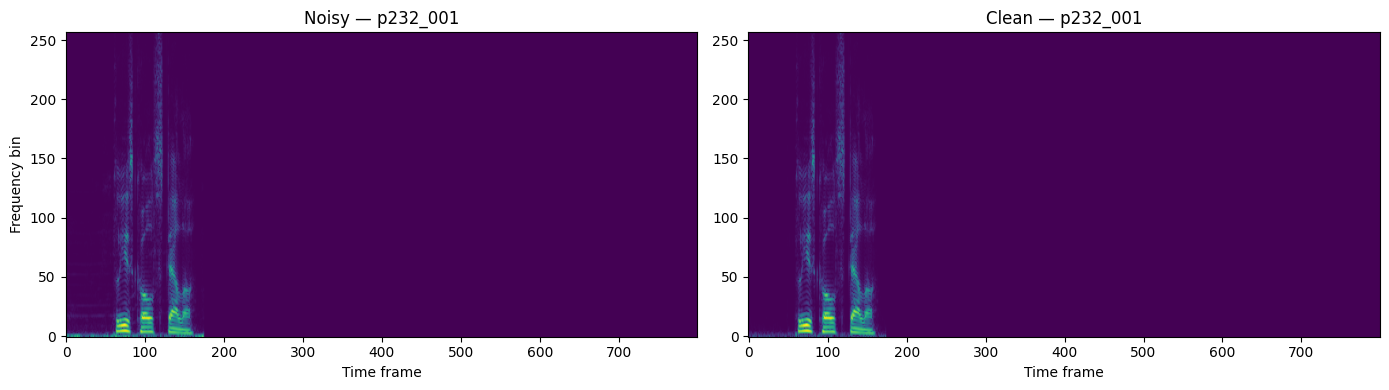

In [ ]:

batch = next(iter(test_loader))

print("Batch keys:", list(batch.keys()))
print(f"noisy_mag  : {batch['noisy_mag'].shape}  dtype={batch['noisy_mag'].dtype}")
print(f"clean_mag  : {batch['clean_mag'].shape}  dtype={batch['clean_mag'].dtype}")
print(f"noisy_phase: {batch['noisy_phase'].shape}")
print(f"lengths    : {batch['lengths']}")
print(f"pair_ids   : {batch['pair_ids']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
idx = 0
axes[0].imshow(batch["noisy_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[0].set_title(f"Noisy — {batch['pair_ids'][idx]}")
axes[0].set_xlabel("Time frame")
axes[0].set_ylabel("Frequency bin")
axes[1].imshow(batch["clean_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[1].set_title(f"Clean — {batch['pair_ids'][idx]}")
axes[1].set_xlabel("Time frame")
plt.tight_layout()
plt.show()

# 4. Model Architecture

This section defines a multi-task speech model with two task-specific attention branches:

- a denoising branch with one DeltaNet time-attention block and one Flash frequency-attention block
- a lighter classifier branch with one DeltaNet time-attention block and one Flash frequency-attention block

The two branches share the CNN encoder, but each branch gets its own time/frequency attention so classification and denoising do not compete for the exact same attention features. The classifier branch is projected to fewer channels than the denoiser branch because noisy/clean classification needs less capacity than full spectrogram reconstruction.

The denoiser predicts both a multiplicative mask and a bounded residual correction. This is more flexible than a mask alone because the model can reduce noise-dominated bins while also adding back speech energy that a pure mask may suppress.

The classifier output is used as a **soft gate** during training and inference. After sigmoid, the noisy probability `p_noisy` controls how much denoising is applied:

`output = (1 - p_noisy) * original + p_noisy * denoised`

When the classifier is confident the sample is clean, `p_noisy` is near 0 and the model mostly passes the original audio through. When the classifier is confident the sample is noisy, `p_noisy` is near 1 and the denoising mask is fully applied.

Input: `noisy_mag [B, 1, 257, T]` (log-magnitude spectrogram)

Output: gated denoised magnitude with the same shape, plus a noisy/clean classification score

STFT parameters: `n_fft=512`, `hop_length=160`, `win_length=400`, `window=hann`, 257 frequency bins.

In [ ]:
from torch.utils.checkpoint import checkpoint as grad_checkpoint

# ---------------------------------------------------------------------------
# Building blocks
# ---------------------------------------------------------------------------

def _norm(out_ch):
    return nn.BatchNorm2d(out_ch)


class FeatureBatchNorm(nn.Module):
    """BatchNorm over the final feature dimension of channel-last tensors."""
    def __init__(self, num_features):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features)

    def forward(self, x):
        original_shape = x.shape
        return self.bn(x.reshape(-1, original_shape[-1])).reshape(original_shape)


class ConvBlock(nn.Module):
    """Conv2d -> BatchNorm -> PReLU. Optionally downsamples frequency via stride."""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=(1, 1), padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding),
            _norm(out_ch),
            nn.PReLU(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class DeconvBlock(nn.Module):
    """ConvTranspose2d -> BatchNorm -> PReLU. Upsamples frequency via stride."""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=(2, 1),
                 padding=1, output_padding=(1, 0)):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, stride=stride,
                               padding=padding, output_padding=output_padding),
            _norm(out_ch),
            nn.PReLU(out_ch),
        )

    def forward(self, x):
        return self.block(x)


# ---------------------------------------------------------------------------
# Attention blocks
# ---------------------------------------------------------------------------

class DeltaNetBlock(nn.Module):
    """BatchNorm DeltaNet attention + FFN with residual connections."""
    def __init__(self, d_model, num_heads, ffn_ratio=4):
        super().__init__()
        self.uses_batchnorm = True
        self.norm1 = FeatureBatchNorm(d_model)
        self.attn = DeltaNet(
            d_model=d_model,
            num_heads=num_heads,
            use_short_conv=True,
            conv_size=4,
            use_beta=True,
        )
        self.norm2 = FeatureBatchNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Linear(d_model * ffn_ratio, d_model),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, *_ = self.attn(h)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x


class FullAttentionBlock(nn.Module):
    """BatchNorm self-attention using Flash Attention via scaled_dot_product_attention."""
    def __init__(self, d_model, num_heads, ffn_ratio=4):
        super().__init__()
        self.uses_batchnorm = True
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.norm1 = FeatureBatchNorm(d_model)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm2 = FeatureBatchNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Linear(d_model * ffn_ratio, d_model),
        )

    def forward(self, x):
        B, T, D = x.shape
        h = self.norm1(x)
        qkv = self.qkv(h).reshape(B, T, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)  # each [B, H, T, D_h]
        h = F.scaled_dot_product_attention(q, k, v)       # Flash Attention, O(T) memory
        h = h.transpose(1, 2).reshape(B, T, D)
        h = self.out_proj(h)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x


# ---------------------------------------------------------------------------
# Main model
# ---------------------------------------------------------------------------

class SpeechDenoiser(nn.Module):
    """
    CNN encoder-decoder with separate time/frequency attention branches for
    denoising and noisy/clean classification.

    Shared encoder:
        Converts the input STFT magnitude into a compact [B, 4C, 65, T] feature map.

    Task-specific attention branches:
        Each branch uses one TF pair by default:
        - TIME  (DeltaNet):      each frequency bin attends across time frames.
        - FREQ  (FullAttention): each time frame attends across frequency bins.
        The denoiser and classifier therefore both see temporal context and
        cross-frequency structure, but their attention parameters are separate.

    Classifier:
        Reads from its own attention branch and produces a noisy/clean logit.
        Its sigmoid probability is later used as a soft gate that controls how
        strongly the denoising mask is applied.

    Outputs:
        mask         [B, 1, 257, T]  sigmoid mask in [0, 1], applied in LINEAR magnitude.
        residual_raw [B, 1, 257, T]  bounded log-magnitude residual correction.
        cls_logit    [B, 1]          noisy/clean classification logit (raw, pre-sigmoid).
    """

    def __init__(self, channels=64, n_heads=8, n_tf_pairs=1, ffn_ratio=4):
        super().__init__()
        C = channels
        bottleneck_dim = C * 4   # denoiser branch width
        cls_dim = C * 2          # lighter classifier branch width
        assert bottleneck_dim % n_heads == 0, "denoiser width must be divisible by n_heads"
        assert cls_dim % n_heads == 0, "classifier width must be divisible by n_heads"

        # --- Encoder ---
        self.enc1 = ConvBlock(1, C)                                  # -> [B, 64, 257, T]
        self.enc2 = ConvBlock(C, C * 2, stride=(2, 1))              # -> [B, 128, 129, T]
        self.enc3 = ConvBlock(C * 2, bottleneck_dim, stride=(2, 1)) # -> [B, 256, 65, T]

        # --- Task-specific attention branches ---
        # Each TF pair runs DeltaNet over time, then Flash Attention over frequency.
        self.denoise_attn_layers = nn.ModuleList()
        self.classify_proj = nn.Conv2d(bottleneck_dim, cls_dim, kernel_size=1)
        self.classify_attn_layers = nn.ModuleList()
        for _ in range(n_tf_pairs):
            self.denoise_attn_layers.append(
                DeltaNetBlock(bottleneck_dim, n_heads, ffn_ratio))
            self.denoise_attn_layers.append(
                FullAttentionBlock(bottleneck_dim, n_heads, ffn_ratio))
            self.classify_attn_layers.append(
                DeltaNetBlock(cls_dim, n_heads, max(1, ffn_ratio // 2)))
            self.classify_attn_layers.append(
                FullAttentionBlock(cls_dim, n_heads, max(1, ffn_ratio // 2)))
        self.denoise_attn_norm = FeatureBatchNorm(bottleneck_dim)
        self.classify_attn_norm = FeatureBatchNorm(cls_dim)

        # --- Decoder (with skip connections) ---
        self.dec3 = DeconvBlock(bottleneck_dim, C * 2, stride=(2, 1),
                                padding=1, output_padding=(1, 0))
        self.dec2 = DeconvBlock(C * 4, C, stride=(2, 1),
                                padding=1, output_padding=(0, 0))
        # Two output channels: mask logits and residual correction.
        self.out = nn.Conv2d(C * 2, 2, kernel_size=3, padding=1)

        # --- Classification head (reads classifier attention output) ---
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(cls_dim, 1),
        )

    def _apply_layer(self, layer, h):
        # Do not checkpoint BatchNorm blocks; recomputation would update running stats twice.
        if self.training and not getattr(layer, "uses_batchnorm", False):
            return grad_checkpoint(layer, h, use_reentrant=False)
        return layer(h)

    def _run_tf_attention(self, e3, layers, norm):
        """
        Run alternating time/frequency attention on an STFT feature map.
        Input : [B, C, F, T]
        Output: [B, C, F, T]

        Even-index layers are DeltaNet blocks over TIME: each frequency bin gets
        the full temporal sequence. Odd-index layers are Flash Attention blocks
        over FREQ: each time frame gets the full set of frequency bins.
        """
        B, C, Fbins, T = e3.shape
        h = e3.permute(0, 2, 3, 1).contiguous()         # [B, F, T, C]

        for i, layer in enumerate(layers):
            if i % 2 == 0:
                # TIME attention: pack F into batch -> [B*F, T, C]
                h = h.reshape(B * Fbins, T, C)
                h = self._apply_layer(layer, h)
                h = h.reshape(B, Fbins, T, C)
            else:
                # FREQ attention: pack T into batch -> [B*T, F, C]
                h = h.transpose(1, 2).contiguous()       # [B, T, F, C]
                h = h.reshape(B * T, Fbins, C)
                h = self._apply_layer(layer, h)
                h = h.reshape(B, T, Fbins, C).transpose(1, 2).contiguous()

        h = norm(h)                                      # BatchNorm over C
        return h.permute(0, 3, 1, 2).contiguous()        # [B, C, F, T]

    def forward(self, x):
        # x: [B, 1, 257, T]  (log1p magnitude)

        # Encoder
        e1 = self.enc1(x)    # [B, C, 257, T]
        e2 = self.enc2(e1)   # [B, 2C, 129, T]
        e3 = self.enc3(e2)   # [B, 4C, 65, T]

        # Separate task-specific TF attention branches.
        denoise_h = self._run_tf_attention(
            e3, self.denoise_attn_layers, self.denoise_attn_norm
        )                                                # [B, 4C, 65, T]
        classify_h = self.classify_proj(e3)              # [B, 2C, 65, T]
        classify_h = self._run_tf_attention(
            classify_h, self.classify_attn_layers, self.classify_attn_norm
        )                                                # [B, 2C, 65, T]

        cls_logit = self.classifier(classify_h)          # [B, 1]

        # Decoder with skip connections
        d3 = self.dec3(denoise_h)                        # [B, 2C, ?, T]
        d3 = d3[..., :e2.shape[-2], :]                   # crop freq to match enc2
        d2 = self.dec2(torch.cat([d3, e2], dim=1))       # [B, C, ?, T]
        d2 = d2[..., :e1.shape[-2], :]                   # crop freq to match enc1
        out = self.out(torch.cat([d2, e1], dim=1))       # [B, 2, 257, T]
        mask = torch.sigmoid(out[:, :1])                 # [B, 1, 257, T]
        residual_raw = out[:, 1:2]                       # [B, 1, 257, T]

        return mask, residual_raw, cls_logit

The following block helps verify the matrix dimensions of the mask and cls. [Expand on this later]

In [ ]:
model = SpeechDenoiser(channels=48, n_heads=4, n_tf_pairs=1, ffn_ratio=2).to(device)
# If you have a larger GPU, you can try: SpeechDenoiser(channels=96, n_heads=4, n_tf_pairs=1, ffn_ratio=4)

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {param_count:,}")

# Shape verification with a dummy input (DeltaNet requires bfloat16)
dummy = torch.randn(2, 1, 257, 100, device=device)
with torch.amp.autocast("cuda", dtype=torch.bfloat16):
    mask, residual_raw, cls_logit = model(dummy)
gate = torch.sigmoid(cls_logit.float()).view(-1, 1, 1, 1)
print(f"Input:        {dummy.shape}")
print(f"Mask:         {mask.shape}  dtype={mask.dtype}")
print(f"Residual raw: {residual_raw.shape}  dtype={residual_raw.dtype}")
print(f"Cls logit:    {cls_logit.shape}")
print(f"Gate:         {gate.shape}  values={gate.flatten().detach().cpu().numpy()}")
print(f"Denoise attention layers:    {len(model.denoise_attn_layers)} (time + freq)")
print(f"Classifier attention layers: {len(model.classify_attn_layers)} (time + freq)")
assert mask.shape == dummy.shape, f"Mask shape mismatch: {mask.shape}"
assert residual_raw.shape == dummy.shape, f"Residual shape mismatch: {residual_raw.shape}"
assert cls_logit.shape == (2, 1), f"Cls shape mismatch: {cls_logit.shape}"
assert gate.shape == (2, 1, 1, 1), f"Gate shape mismatch: {gate.shape}"
assert len(model.denoise_attn_layers) == 2, "Denoiser should have 1 DeltaNet + 1 FlashAttention layer"
assert len(model.classify_attn_layers) == 2, "Classifier should have 1 DeltaNet + 1 FlashAttention layer"
print("Shape verification passed.")

Model parameters: 1,189,563
Input:        torch.Size([2, 1, 257, 100])
Mask:         torch.Size([2, 1, 257, 100])  dtype=torch.bfloat16
Residual raw: torch.Size([2, 1, 257, 100])  dtype=torch.bfloat16
Cls logit:    torch.Size([2, 1])
Gate:         torch.Size([2, 1, 1, 1])  values=[0.52013075 0.52476   ]
Denoise attention layers:    2 (time + freq)
Classifier attention layers: 2 (time + freq)
Shape verification passed.


# 5. Training

![reddit xkcd comic](https://i.redd.it/5cjdqxcg07k11.png)

The following code allows us to run one epoch at a time, then save and come back later. This is implemented to prevent the training from crashing and losing all of our progress.

Gate control is implemented in the loss helper below. The model predicts a denoising mask, a bounded residual correction, and a classifier logit. The denoised estimate is produced by applying the mask in linear magnitude and then adding a small residual correction in log-magnitude space.

The final magnitude is blended with the classifier probability:

`gated = original + p_noisy * (denoised - original)`

This is equivalent to `(1 - p_noisy) * original + p_noisy * denoised`. Clean examples are included in the training batch with label `0` and target equal to themselves, so the classifier learns to keep the gate closed for clean audio. During the first few epochs, training uses the known noisy/clean labels as an oracle gate so the denoiser learns before the predicted classifier gate controls the reconstruction loss.

In [ ]:
# ---------------------------------------------------------------------------
# Checkpoint utilities
# ---------------------------------------------------------------------------

# For Colab: mount Google Drive and point CHECKPOINT_DIR there.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
CHECKPOINT_DIR = '/content/drive/MyDrive/batch_ablation_checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(model, optimizer, scheduler, epoch, history, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Resumed from epoch {ckpt['epoch']}")
    return ckpt["epoch"], ckpt["history"]


# ---------------------------------------------------------------------------
# Training & evaluation
# ---------------------------------------------------------------------------

LAMBDA_CLS = 0.1
LAMBDA_SC = 0.1
GATE_WARMUP_EPOCHS = 5
GATE_TEMPERATURE = 1.0       # lower = sharper noisy/clean gate; 1.0 is standard sigmoid
RESIDUAL_SCALE = 0.5         # max absolute log-magnitude correction from residual head
DETACH_GATE_FOR_DENOISE = False
classify_criterion = nn.BCEWithLogitsLoss()

GRAD_ACCUM_STEPS = 2   # effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS = 8 * 2 = 16


def noise_gate_from_logits(cls_logit, temperature=GATE_TEMPERATURE):
    """Convert noisy/clean logits into a broadcastable soft gate in [0, 1]."""
    return torch.sigmoid(cls_logit.float() / temperature).view(-1, 1, 1, 1)


def apply_gated_hybrid_in_linear(
    mask,
    residual_raw,
    cls_logit,
    noisy_log_mag,
    oracle_gate=None,
    gate_temperature=GATE_TEMPERATURE,
    detach_gate=DETACH_GATE_FOR_DENOISE,
):
    """
    Apply hybrid mask+residual denoising through classifier-controlled soft gating.

    The mask removes energy in linear magnitude. The residual is a bounded
    log-magnitude correction that can add back speech energy after masking.
    The gate then blends between the original and denoised magnitudes:
        gated = (1 - p_noisy) * noisy + p_noisy * denoised
    """
    noisy_lin = torch.expm1(noisy_log_mag.float())
    masked_log = torch.log1p((mask.float() * noisy_lin).clamp(min=0.0))
    residual_log = RESIDUAL_SCALE * torch.tanh(residual_raw.float())
    denoised_log = (masked_log + residual_log).clamp(min=0.0)
    denoised_lin = torch.expm1(denoised_log)

    if oracle_gate is None:
        gate = noise_gate_from_logits(cls_logit, gate_temperature)
    else:
        gate = oracle_gate.float().view(-1, 1, 1, 1)
    if detach_gate:
        gate = gate.detach()

    gated_lin = noisy_lin + gate * (denoised_lin - noisy_lin)
    return torch.log1p(gated_lin.clamp(min=0.0)), gate


def _time_mask_like(x, lengths):
    B, C, Fbins, T = x.shape
    time_mask = torch.arange(T, device=x.device)[None, :] < lengths[:, None]
    return time_mask[:, None, None, :].expand(B, C, Fbins, T).to(x.dtype)


def masked_l1_loss(est_log, target_log, lengths):
    """L1 averaged only over real (non-padded) time frames."""
    time_mask = _time_mask_like(est_log, lengths)
    abs_err = (est_log - target_log).abs() * time_mask
    return abs_err.sum() / time_mask.sum().clamp(min=1.0)


def masked_spectral_convergence_loss(est_log, target_log, lengths):
    """Relative linear-magnitude error, averaged per item over non-padded frames."""
    time_mask = _time_mask_like(est_log, lengths)
    est_lin = torch.expm1(est_log.float()) * time_mask
    target_lin = torch.expm1(target_log.float()) * time_mask
    diff = (est_lin - target_lin).reshape(est_log.shape[0], -1)
    target_flat = target_lin.reshape(target_log.shape[0], -1)
    numerator = torch.linalg.vector_norm(diff, ord=2, dim=1)
    denominator = torch.linalg.vector_norm(target_flat, ord=2, dim=1).clamp(min=1e-8)
    return (numerator / denominator).mean()


def _build_multitask_batch(noisy_mag, clean_mag, lengths, device):
    """
    Stack [noisy, clean] along the batch dim so the model sees both in one forward.
    - Noisy inputs should reconstruct the paired clean target.
    - Clean inputs should reconstruct themselves, which teaches the gate to stay quiet.
    - Classification loss uses both halves (noisy=1, clean=0).
    """
    inputs  = torch.cat([noisy_mag, clean_mag], dim=0)      # [2B, 1, 257, T]
    targets = torch.cat([clean_mag, clean_mag], dim=0)      # [2B, 1, 257, T]
    target_lengths = torch.cat([lengths, lengths], dim=0)   # [2B]
    B = noisy_mag.shape[0]
    labels  = torch.cat(
        [torch.ones(B, 1, device=device), torch.zeros(B, 1, device=device)],
        dim=0,
    )                                                       # [2B, 1]
    return inputs, targets, target_lengths, labels


def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    use_oracle_gate = epoch <= GATE_WARMUP_EPOCHS
    running_l1 = 0.0
    running_sc = 0.0
    running_cls = 0.0
    n = 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        noisy_mag = batch["noisy_mag"].to(device)   # [B, 1, 257, T] log1p mag
        clean_mag = batch["clean_mag"].to(device)
        lengths   = batch["lengths"].to(device)

        inputs, targets, target_lengths, labels = _build_multitask_batch(
            noisy_mag, clean_mag, lengths, device
        )

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            mask_all, residual_all, cls_logit = model(inputs)  # [2B,1,257,T], [2B,1,257,T], [2B,1]

        # During warmup, use the known noisy/clean labels as the gate so the
        # denoiser learns before relying on the predicted classifier gate.
        oracle_gate = labels if use_oracle_gate else None
        est_log, _ = apply_gated_hybrid_in_linear(
            mask_all, residual_all, cls_logit, inputs, oracle_gate=oracle_gate
        )
        l1_loss = masked_l1_loss(est_log, targets, target_lengths)
        sc_loss = masked_spectral_convergence_loss(est_log, targets, target_lengths)
        denoise_loss = l1_loss + LAMBDA_SC * sc_loss

        # Classification: supervise on both halves.
        cls_loss = classify_criterion(cls_logit.float(), labels)

        loss = (denoise_loss + LAMBDA_CLS * cls_loss) / GRAD_ACCUM_STEPS
        loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        running_l1  += l1_loss.item()
        running_sc  += sc_loss.item()
        running_cls += cls_loss.item()
        n += 1

    return running_l1 / max(n, 1), running_sc / max(n, 1), running_cls / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_l1 = 0.0
    running_sc = 0.0
    running_cls = 0.0
    n = 0

    for batch in loader:
        noisy_mag = batch["noisy_mag"].to(device)
        clean_mag = batch["clean_mag"].to(device)
        lengths   = batch["lengths"].to(device)

        inputs, targets, target_lengths, labels = _build_multitask_batch(
            noisy_mag, clean_mag, lengths, device
        )

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            mask_all, residual_all, cls_logit = model(inputs)

        est_log, _ = apply_gated_hybrid_in_linear(mask_all, residual_all, cls_logit, inputs)
        l1_loss = masked_l1_loss(est_log, targets, target_lengths)
        sc_loss = masked_spectral_convergence_loss(est_log, targets, target_lengths)
        cls_loss = classify_criterion(cls_logit.float(), labels)

        running_l1  += l1_loss.item()
        running_sc  += sc_loss.item()
        running_cls += cls_loss.item()
        n += 1

    return running_l1 / max(n, 1), running_sc / max(n, 1), running_cls / max(n, 1)

Mounted at /content/drive


This is the main training loop. It calls the functions defined above to train. Currently, the total training will go through 50 epochs.

In [ ]:
# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
EPOCHS     = 50
LR         = 3e-4
SAVE_EVERY = 5          # save checkpoint every N epochs

torch.cuda.empty_cache()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

start_epoch = 0
history = {
    "train_l1": [], "train_sc": [], "train_cls": [], "train_total": [],
    "test_l1": [], "test_sc": [], "test_cls": [], "test_total": [],
}

resume_path = os.path.join(CHECKPOINT_DIR, "latest.pt")
if os.path.exists(resume_path):
    start_epoch, history = load_checkpoint(resume_path, model, optimizer, scheduler)
    for k in ("train_l1", "train_sc", "train_cls", "train_total",
              "test_l1", "test_sc", "test_cls", "test_total"):
        history.setdefault(k, [])

# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------
best_test_total = min(history["test_total"]) if history["test_total"] else float("inf")

for epoch in range(start_epoch + 1, EPOCHS + 1):
    t0 = time.perf_counter()

    train_l1, train_sc, train_cls = train_one_epoch(model, train_loader, optimizer, device, epoch)
    test_l1,  test_sc,  test_cls  = evaluate(model, test_loader, device)
    train_total = train_l1 + LAMBDA_SC * train_sc
    test_total = test_l1 + LAMBDA_SC * test_sc

    scheduler.step()
    elapsed = time.perf_counter() - t0

    history["train_l1"].append(train_l1)
    history["train_sc"].append(train_sc)
    history["train_cls"].append(train_cls)
    history["train_total"].append(train_total)
    history["test_l1"].append(test_l1)
    history["test_sc"].append(test_sc)
    history["test_cls"].append(test_cls)
    history["test_total"].append(test_total)

    lr_now = scheduler.get_last_lr()[0]
    gate_mode = "oracle" if epoch <= GATE_WARMUP_EPOCHS else "pred"
    print(f"Epoch {epoch:03d}/{EPOCHS} ({elapsed:.0f}s, gate={gate_mode}) | "
          f"Train L1={train_l1:.4f} SC={train_sc:.4f} cls={train_cls:.4f} | "
          f"Test  L1={test_l1:.4f} SC={test_sc:.4f} cls={test_cls:.4f} | "
          f"LR={lr_now:.2e}")

    # Save best model using the reconstruction objective: L1 + LAMBDA_SC * spectral convergence.
    if test_total < best_test_total:
        best_test_total = test_total
        save_checkpoint(model, optimizer, scheduler, epoch, history,
                        os.path.join(CHECKPOINT_DIR, "best.pt"))
        print(f"  -> New best test total: {best_test_total:.4f}")

    # Periodic checkpoint
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(model, optimizer, scheduler, epoch, history,
                        os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pt"))

    # Always save latest (for resume)
    save_checkpoint(model, optimizer, scheduler, epoch, history,
                    os.path.join(CHECKPOINT_DIR, "latest.pt"))

print(f"\nTraining complete. Best test total: {best_test_total:.4f}")

Epoch 001/50 (1503s, gate=oracle) | Train L1=0.0206 SC=0.1093 cls=0.0233 | Test  L1=0.0122 SC=0.0584 cls=0.0942 | LR=3.00e-04
  -> New best test total: 0.0180
Epoch 002/50 (673s, gate=oracle) | Train L1=0.0170 SC=0.0895 cls=0.0079 | Test  L1=0.0119 SC=0.0643 cls=0.1449 | LR=2.99e-04
Epoch 003/50 (673s, gate=oracle) | Train L1=0.0160 SC=0.0833 cls=0.0058 | Test  L1=0.0113 SC=0.0580 cls=0.1836 | LR=2.97e-04
  -> New best test total: 0.0171
Epoch 004/50 (673s, gate=oracle) | Train L1=0.0154 SC=0.0797 cls=0.0046 | Test  L1=0.0109 SC=0.0542 cls=0.1874 | LR=2.95e-04
  -> New best test total: 0.0164
Epoch 005/50 (593s, gate=oracle) | Train L1=0.0150 SC=0.0773 cls=0.0040 | Test  L1=0.0112 SC=0.0604 cls=0.1465 | LR=2.93e-04
Epoch 006/50 (594s, gate=pred) | Train L1=0.0147 SC=0.0755 cls=0.0038 | Test  L1=0.0109 SC=0.0574 cls=0.3200 | LR=2.89e-04
Epoch 007/50 (591s, gate=pred) | Train L1=0.0144 SC=0.0738 cls=0.0034 | Test  L1=0.0110 SC=0.0598 cls=0.3572 | LR=2.86e-04
Epoch 008/50 (674s, gate=pred

The following code plots the classification loss per epoch trained.

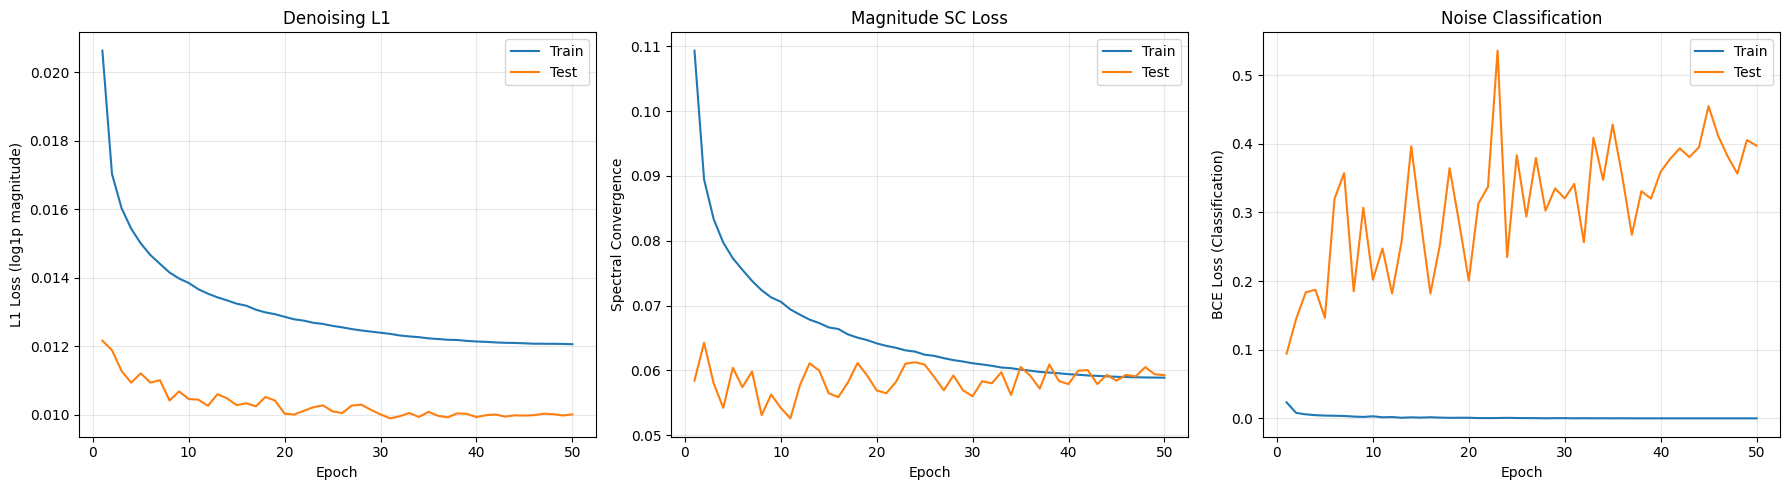

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history["train_l1"]) + 1)

ax1.plot(epochs_range, history["train_l1"], label="Train")
ax1.plot(epochs_range, history["test_l1"],  label="Test")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("L1 Loss (log1p magnitude)")
ax1.set_title("Denoising L1")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_sc"], label="Train")
ax2.plot(epochs_range, history["test_sc"],  label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Spectral Convergence")
ax2.set_title("Magnitude SC Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(epochs_range, history["train_cls"], label="Train")
ax3.plot(epochs_range, history["test_cls"],  label="Test")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("BCE Loss (Classification)")
ax3.set_title("Noise Classification")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Quick test cell: load best.pt, plot saved training curves, evaluate test_loader,
# compute PESQ, and listen to a few denoised examples.
# ---------------------------------------------------------------------------
import IPython.display as ipd

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as exc:
    print(f"Drive mount skipped: {exc}")

try:
    from torch_pesq import PesqLoss
except Exception as exc:
    PesqLoss = None
    print(f"torch_pesq is not available, so PESQ metrics will be skipped. Install with `pip install torch-pesq`. ({exc})")

CHECKPOINT_DIR = '/content/drive/MyDrive/batch_ablation_checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
QUICK_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best.pt")
QUICK_NUM_AUDIO = 4
QUICK_MAX_EVAL_BATCHES = None  # set to a small number like 10 for a faster smoke test
QUICK_COMPUTE_PESQ = True      # PESQ is slower because it reconstructs waveforms
quick_classify_criterion = nn.BCEWithLogitsLoss()

N_FFT = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
SAMPLE_RATE = 16_000
quick_window = torch.hann_window(WIN_LENGTH)
quick_pesq = PesqLoss(0.5, sample_rate=SAMPLE_RATE) if (PesqLoss is not None and QUICK_COMPUTE_PESQ) else None


def quick_noise_gate_from_logits(cls_logit, temperature=1.0):
    return torch.sigmoid(cls_logit.float() / temperature).view(-1, 1, 1, 1)


def quick_apply_gated_hybrid_in_linear(
    mask,
    residual_raw,
    cls_logit,
    noisy_log_mag,
    gate_temperature=1.0,
    residual_scale=0.5,
):
    """Same inference logic as training: mask + residual, then classifier gate."""
    noisy_lin = torch.expm1(noisy_log_mag.float())
    masked_log = torch.log1p((mask.float() * noisy_lin).clamp(min=0.0))
    residual_log = residual_scale * torch.tanh(residual_raw.float())
    denoised_log = (masked_log + residual_log).clamp(min=0.0)
    denoised_lin = torch.expm1(denoised_log)
    gate = quick_noise_gate_from_logits(cls_logit, gate_temperature)
    gated_lin = noisy_lin + gate * (denoised_lin - noisy_lin)
    return torch.log1p(gated_lin.clamp(min=0.0)), gate


def quick_time_mask_like(x, lengths):
    B, C, Fbins, T = x.shape
    time_mask = torch.arange(T, device=x.device)[None, :] < lengths[:, None]
    return time_mask[:, None, None, :].expand(B, C, Fbins, T).to(x.dtype)


def quick_masked_l1(est_log, target_log, lengths):
    time_mask = quick_time_mask_like(est_log, lengths)
    return ((est_log - target_log).abs() * time_mask).sum() / time_mask.sum().clamp(min=1.0)


def quick_masked_spectral_convergence(est_log, target_log, lengths):
    time_mask = quick_time_mask_like(est_log, lengths)
    est_lin = torch.expm1(est_log.float()) * time_mask
    target_lin = torch.expm1(target_log.float()) * time_mask
    diff = (est_lin - target_lin).reshape(est_log.shape[0], -1)
    target_flat = target_lin.reshape(target_log.shape[0], -1)
    numerator = torch.linalg.vector_norm(diff, ord=2, dim=1)
    denominator = torch.linalg.vector_norm(target_flat, ord=2, dim=1).clamp(min=1e-8)
    return (numerator / denominator).mean()


def quick_istft_from_mag_phase(mag, phase):
    stft_complex = torch.polar(mag, phase)
    return torch.istft(
        stft_complex,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window=quick_window,
    )


def quick_normalize_pair(reference, degraded):
    """Normalize a waveform pair together so PESQ gets stable audio scale."""
    scale = torch.maximum(reference.abs().max(), degraded.abs().max()).clamp(min=1e-8)
    return reference / scale, degraded / scale


def quick_pesq_pair(reference, degraded):
    """Return (PESQ MOS, PESQ loss) for one waveform pair, or (None, None)."""
    if quick_pesq is None:
        return None, None
    length = min(reference.numel(), degraded.numel())
    if length == 0:
        return None, None
    reference = reference[:length].float()
    degraded = degraded[:length].float()
    reference, degraded = quick_normalize_pair(reference, degraded)
    reference = reference.unsqueeze(0)
    degraded = degraded.unsqueeze(0)
    try:
        mos = quick_pesq.mos(reference, degraded)
        loss = quick_pesq(reference, degraded)
        return float(mos.detach().cpu().mean()), float(loss.detach().cpu().mean())
    except Exception as exc:
        print(f"PESQ failed for one sample and was skipped: {exc}")
        return None, None


def quick_batch_pesq(est_log, clean_log, noisy_phase, lengths):
    """
    Compute PESQ on the noisy-input half of a batch.

    Note: test_loader contains noisy_phase but not clean_phase, so the clean
    reference is reconstructed with noisy_phase here. This keeps evaluation
    compatible with the existing test_loader, but true clean-phase PESQ would
    require adding clean_phase to collate_magnitude or reading from test_ds.
    """
    if quick_pesq is None:
        return None, None

    mos_values = []
    loss_values = []
    for i in range(est_log.shape[0]):
        T = int(lengths[i].item())
        denoised_mag = torch.expm1(est_log[i, 0, :, :T].float()).cpu()
        clean_mag = torch.expm1(clean_log[i, 0, :, :T].float()).cpu()
        phase = noisy_phase[i, :, :T].float().cpu()
        wav_denoised = quick_istft_from_mag_phase(denoised_mag, phase)
        wav_clean = quick_istft_from_mag_phase(clean_mag, phase)
        mos, loss = quick_pesq_pair(wav_clean, wav_denoised)
        if mos is not None:
            mos_values.append(mos)
            loss_values.append(loss)

    if not mos_values:
        return None, None
    return float(np.mean(mos_values)), float(np.mean(loss_values))


@torch.no_grad()
def quick_evaluate_model(model, loader, device, max_batches=None):
    model.eval()
    running_l1 = 0.0
    running_sc = 0.0
    running_cls = 0.0
    running_acc = 0.0
    running_pesq_mos = 0.0
    running_pesq_loss = 0.0
    pesq_batches = 0
    n = 0

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        noisy_mag = batch["noisy_mag"].to(device)
        clean_mag = batch["clean_mag"].to(device)
        lengths = batch["lengths"].to(device)
        B = noisy_mag.shape[0]

        inputs = torch.cat([noisy_mag, clean_mag], dim=0)
        targets = torch.cat([clean_mag, clean_mag], dim=0)
        target_lengths = torch.cat([lengths, lengths], dim=0)
        labels = torch.cat(
            [torch.ones(B, 1, device=device), torch.zeros(B, 1, device=device)],
            dim=0,
        )

        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
            mask, residual_raw, cls_logit = model(inputs)

        est_log, _ = quick_apply_gated_hybrid_in_linear(
            mask, residual_raw, cls_logit, inputs,
            gate_temperature=globals().get("GATE_TEMPERATURE", 1.0),
            residual_scale=globals().get("RESIDUAL_SCALE", 0.5),
        )
        cls_loss = quick_classify_criterion(cls_logit.float(), labels)
        cls_pred = (torch.sigmoid(cls_logit.float()) >= 0.5).float()
        cls_acc = (cls_pred == labels).float().mean()

        running_l1 += quick_masked_l1(est_log, targets, target_lengths).item()
        running_sc += quick_masked_spectral_convergence(est_log, targets, target_lengths).item()
        running_cls += cls_loss.item()
        running_acc += cls_acc.item()

        pesq_mos, pesq_loss = quick_batch_pesq(
            est_log[:B], clean_mag, batch["noisy_phase"], batch["lengths"]
        )
        if pesq_mos is not None:
            running_pesq_mos += pesq_mos
            running_pesq_loss += pesq_loss
            pesq_batches += 1

        n += 1

    return {
        "l1": running_l1 / max(n, 1),
        "spectral_convergence": running_sc / max(n, 1),
        "classification_bce": running_cls / max(n, 1),
        "classification_accuracy": running_acc / max(n, 1),
        "pesq_mos": running_pesq_mos / max(pesq_batches, 1) if pesq_batches else None,
        "pesq_loss": running_pesq_loss / max(pesq_batches, 1) if pesq_batches else None,
        "batches": n,
        "pesq_batches": pesq_batches,
    }


if not os.path.exists(QUICK_CHECKPOINT_PATH):
    raise FileNotFoundError(f"Could not find best checkpoint: {QUICK_CHECKPOINT_PATH}")

quick_model = SpeechDenoiser(channels=48, n_heads=4, n_tf_pairs=1, ffn_ratio=2).to(device)
quick_ckpt = torch.load(QUICK_CHECKPOINT_PATH, map_location=device, weights_only=False)
quick_model.load_state_dict(quick_ckpt["model_state_dict"])
quick_model.eval()
quick_history = quick_ckpt.get("history", {})
print(f"Loaded best checkpoint from epoch {quick_ckpt.get('epoch', '?')}: {QUICK_CHECKPOINT_PATH}")

# Plot training curves saved in best.pt.
if quick_history.get("test_l1"):
    epochs_range = range(1, len(quick_history["test_l1"]) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    ax1.plot(epochs_range, quick_history.get("train_l1", []), label="Train")
    ax1.plot(epochs_range, quick_history.get("test_l1", []), label="Test")
    ax1.set_title("Denoising L1")
    ax1.set_xlabel("Epoch")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(epochs_range, quick_history.get("train_sc", []), label="Train")
    ax2.plot(epochs_range, quick_history.get("test_sc", []), label="Test")
    ax2.set_title("Spectral Convergence")
    ax2.set_xlabel("Epoch")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(epochs_range, quick_history.get("train_cls", []), label="Train")
    ax3.plot(epochs_range, quick_history.get("test_cls", []), label="Test")
    ax3.set_title("Classification BCE")
    ax3.set_xlabel("Epoch")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No saved history found in checkpoint; skipping training-curve plots.")

# Evaluate best.pt on the existing test_loader.
metrics = quick_evaluate_model(
    quick_model,
    test_loader,
    device,
    max_batches=QUICK_MAX_EVAL_BATCHES,
)
print("\nBest checkpoint test_loader metrics:")
for key, value in metrics.items():
    if value is None:
        print(f"  {key}: skipped")
    else:
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

# Listen to a few examples from the same test_loader.
batch = next(iter(test_loader))
noisy_log = batch["noisy_mag"].to(device)
lengths = batch["lengths"]

with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
    mask, residual_raw, cls_logit = quick_model(noisy_log)
    est_log, gate = quick_apply_gated_hybrid_in_linear(
        mask, residual_raw, cls_logit, noisy_log,
        gate_temperature=globals().get("GATE_TEMPERATURE", 1.0),
        residual_scale=globals().get("RESIDUAL_SCALE", 0.5),
    )

num_audio = min(QUICK_NUM_AUDIO, noisy_log.shape[0])
for i in range(num_audio):
    T = int(lengths[i].item())
    pair_id = batch.get("pair_ids", [f"sample_{i}"] * num_audio)[i]
    p_noisy = float(gate[i].cpu().item())

    noisy_mag = torch.expm1(batch["noisy_mag"][i, 0, :, :T].float()).cpu()
    clean_mag = torch.expm1(batch["clean_mag"][i, 0, :, :T].float()).cpu()
    denoised_mag = torch.expm1(est_log[i, 0, :, :T].float()).cpu()
    noisy_phase = batch["noisy_phase"][i, :, :T].float().cpu()

    wav_noisy_t = quick_istft_from_mag_phase(noisy_mag, noisy_phase)
    wav_denoised_t = quick_istft_from_mag_phase(denoised_mag, noisy_phase)
    wav_clean_t = quick_istft_from_mag_phase(clean_mag, noisy_phase)
    sample_pesq_mos, sample_pesq_loss = quick_pesq_pair(wav_clean_t, wav_denoised_t)

    wav_noisy = wav_noisy_t.numpy()
    wav_denoised = wav_denoised_t.numpy()
    wav_clean = wav_clean_t.numpy()

    print(f"\n{'=' * 60}")
    print(f"Sample: {pair_id}")
    print(f"Classifier noise gate: {p_noisy:.3f} (0=pass through, 1=full denoise)")
    if sample_pesq_mos is not None:
        print(f"PESQ MOS: {sample_pesq_mos:.3f} | PESQ loss: {sample_pesq_loss:.4f}")
    print(f"{'=' * 60}")

    print("Noisy:")
    ipd.display(ipd.Audio(wav_noisy, rate=SAMPLE_RATE))
    print("Denoised:")
    ipd.display(ipd.Audio(wav_denoised, rate=SAMPLE_RATE))
    print("Clean target:")
    ipd.display(ipd.Audio(wav_clean, rate=SAMPLE_RATE))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, mag, title in zip(
        axes,
        [noisy_mag, denoised_mag, clean_mag],
        ["Noisy", "Denoised", "Clean"],
    ):
        ax.imshow(np.log1p(mag), aspect="auto", origin="lower", cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Frequency bin")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# 6. Audio Listening Test

Here we reconstruct waveforms from the STFT spectrograms using iSTFT. Then, we can listen several examples of **noisy, denoised, and clean** audio and audibly compare our model to the actual clean version.

In [ ]:
# ---------------------------------------------------------------------------
# Load checkpoint weights (skip training - run this instead of the training loop)
# ---------------------------------------------------------------------------
CHECKPOINT_PATH = "/content/drive/MyDrive/batch_ablation_checkpoint/best.pt"

# Must match the model size used during training.
model = SpeechDenoiser(channels=48, n_heads=4, n_tf_pairs=1, ffn_ratio=2).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

history = ckpt.get("history", {
    "train_l1": [], "train_sc": [], "train_cls": [], "train_total": [],
    "test_l1": [], "test_sc": [], "test_cls": [], "test_total": [],
})
loaded_epoch = ckpt.get("epoch", "?")

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Loaded checkpoint from epoch {loaded_epoch}: {CHECKPOINT_PATH}")
print(f"Model parameters: {param_count:,}")
print("Model set to eval mode — ready for graph and test cells.")

Loaded checkpoint from epoch 34: /content/drive/MyDrive/batch_ablation_checkpoint/best.pt
Model parameters: 1,189,563
Model set to eval mode — ready for graph and test cells.


In [ ]:
import IPython.display as ipd

# ── STFT parameters (must match preprocessing) ──────────────────────────
N_FFT      = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
SAMPLE_RATE = 16_000
window = torch.hann_window(WIN_LENGTH)


def istft_from_mag_phase(mag, phase, length=None):
    """Reconstruct a waveform from magnitude and phase tensors."""
    stft_complex = torch.polar(mag, phase)            # mag * exp(j*phase)
    wav = torch.istft(
        stft_complex,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window=window,
        length=length,
    )
    return wav


def denoise_and_reconstruct(model, test_ds, idx, device):
    """
    Run the model on a single test sample and return three waveforms:
    noisy, denoised, clean (all numpy arrays at SAMPLE_RATE).
    """
    sample = test_ds[idx]
    noisy_stft = sample["noisy"]   # complex64 [257, T]
    clean_stft = sample["clean"]   # complex64 [257, T]

    noisy_mag, noisy_phase = stft_to_mag_phase(noisy_stft)
    clean_mag, clean_phase = stft_to_mag_phase(clean_stft)

    noisy_log_mag = torch.log1p(noisy_mag).unsqueeze(0).unsqueeze(0)  # [1, 1, 257, T]

    model.eval()
    with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
        mask, residual_raw, cls_logit = model(noisy_log_mag.to(device))
        est_log_mag, gate_tensor = apply_gated_hybrid_in_linear(
            mask, residual_raw, cls_logit, noisy_log_mag.to(device)
        )
    gate = gate_tensor.cpu().item()
    denoised_mag = torch.expm1(est_log_mag.float()).cpu().squeeze(0).squeeze(0)

    wav_noisy    = istft_from_mag_phase(noisy_mag, noisy_phase)
    wav_denoised = istft_from_mag_phase(denoised_mag, noisy_phase)
    wav_clean    = istft_from_mag_phase(clean_mag, clean_phase)

    return (
        wav_noisy.numpy(),
        wav_denoised.numpy(),
        wav_clean.numpy(),
        noisy_mag.numpy(),
        denoised_mag.numpy(),
        clean_mag.numpy(),
        sample["pair_id"],
        gate,
    )

NUM_SAMPLES = 4
test_indices = random.sample(range(len(test_ds)), NUM_SAMPLES)

for idx in test_indices:
    (wav_n, wav_d, wav_c,
     mag_n, mag_d, mag_c, pair_id, gate) = denoise_and_reconstruct(model, test_ds, idx, device)

    print(f"\n{'='*60}")
    print(f"Sample: {pair_id}  (test index {idx})")
    print(f"Classifier noise gate: {gate:.3f} (0=pass through, 1=full denoise)")
    print(f"{'='*60}")

    # ── Audio players ──
    print("▸ Noisy:")
    ipd.display(ipd.Audio(wav_n, rate=SAMPLE_RATE))
    print("▸ Denoised (model output):")
    ipd.display(ipd.Audio(wav_d, rate=SAMPLE_RATE))
    print("▸ Clean (ground truth):")
    ipd.display(ipd.Audio(wav_c, rate=SAMPLE_RATE))

    # ── Spectrogram comparison ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, mag, title in zip(axes,
                               [mag_n, mag_d, mag_c],
                               ["Noisy", "Denoised", "Clean"]):
        ax.imshow(
            np.log1p(mag),
            aspect="auto", origin="lower",
            cmap="magma",
        )
        ax.set_title(title)
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Frequency bin")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip install speechscore

In [ ]:
# ---------------------------------------------------------------------------
# Quick test cell: load best.pt, plot saved training curves, evaluate test_loader,
# compute PESQ/CSIG/CBAK/COVL, and listen to a few denoised examples.
# ---------------------------------------------------------------------------
import IPython.display as ipd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as exc:
    print(f"Drive mount skipped: {exc}")

try:
    from torch_pesq import PesqLoss
except Exception as exc:
    PesqLoss = None
    print(f"torch_pesq is not available, so PESQ loss will be skipped. Install with `pip install torch-pesq`. ({exc})")

try:
    from pesq import pesq as quick_pesq_mos_fn
except Exception:
    quick_pesq_mos_fn = None

try:
    from pysepm import composite as quick_pysepm_composite
except Exception as exc:
    quick_pysepm_composite = None
    print(f"pysepm is not available, so CSIG/CBAK/COVL will use local composite formulas. Install with `pip install pysepm` for the reference implementation. ({exc})")

CHECKPOINT_DIR = '/content/drive/MyDrive/batch_ablation_checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
QUICK_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "best.pt")
QUICK_NUM_AUDIO = 4
QUICK_MAX_EVAL_BATCHES = None  # set to a small number like 10 for a faster smoke test
QUICK_COMPUTE_PESQ = True      # PESQ is slower because it reconstructs waveforms
QUICK_COMPUTE_COMPOSITE = True # CSIG/CBAK/COVL reuse reconstructed waveforms
quick_classify_criterion = nn.BCEWithLogitsLoss()

N_FFT = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
SAMPLE_RATE = 16_000
quick_window = torch.hann_window(WIN_LENGTH)
quick_pesq = PesqLoss(0.5, sample_rate=SAMPLE_RATE) if (PesqLoss is not None and QUICK_COMPUTE_PESQ) else None


def quick_noise_gate_from_logits(cls_logit, temperature=1.0):
    return torch.sigmoid(cls_logit.float() / temperature).view(-1, 1, 1, 1)


def quick_apply_gated_hybrid_in_linear(
    mask,
    residual_raw,
    cls_logit,
    noisy_log_mag,
    gate_temperature=1.0,
    residual_scale=0.5,
):
    """Same inference logic as training: mask + residual, then classifier gate."""
    noisy_lin = torch.expm1(noisy_log_mag.float())
    masked_log = torch.log1p((mask.float() * noisy_lin).clamp(min=0.0))
    residual_log = residual_scale * torch.tanh(residual_raw.float())
    denoised_log = (masked_log + residual_log).clamp(min=0.0)
    denoised_lin = torch.expm1(denoised_log)
    gate = quick_noise_gate_from_logits(cls_logit, gate_temperature)
    gated_lin = noisy_lin + gate * (denoised_lin - noisy_lin)
    return torch.log1p(gated_lin.clamp(min=0.0)), gate


def quick_time_mask_like(x, lengths):
    B, C, Fbins, T = x.shape
    time_mask = torch.arange(T, device=x.device)[None, :] < lengths[:, None]
    return time_mask[:, None, None, :].expand(B, C, Fbins, T).to(x.dtype)


def quick_masked_l1(est_log, target_log, lengths):
    time_mask = quick_time_mask_like(est_log, lengths)
    return ((est_log - target_log).abs() * time_mask).sum() / time_mask.sum().clamp(min=1.0)


def quick_masked_spectral_convergence(est_log, target_log, lengths):
    time_mask = quick_time_mask_like(est_log, lengths)
    est_lin = torch.expm1(est_log.float()) * time_mask
    target_lin = torch.expm1(target_log.float()) * time_mask
    diff = (est_lin - target_lin).reshape(est_log.shape[0], -1)
    target_flat = target_lin.reshape(target_log.shape[0], -1)
    numerator = torch.linalg.vector_norm(diff, ord=2, dim=1)
    denominator = torch.linalg.vector_norm(target_flat, ord=2, dim=1).clamp(min=1e-8)
    return (numerator / denominator).mean()


def quick_istft_from_mag_phase(mag, phase):
    stft_complex = torch.polar(mag, phase)
    return torch.istft(
        stft_complex,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window=quick_window,
    )


def quick_normalize_pair(reference, degraded):
    """Normalize a waveform pair together so PESQ gets stable audio scale."""
    scale = torch.maximum(reference.abs().max(), degraded.abs().max()).clamp(min=1e-8)
    return reference / scale, degraded / scale


def quick_pesq_pair(reference, degraded):
    """Return (PESQ MOS, PESQ loss) for one waveform pair, or (None, None)."""
    if not QUICK_COMPUTE_PESQ or (quick_pesq is None and quick_pesq_mos_fn is None):
        return None, None
    length = min(reference.numel(), degraded.numel())
    if length == 0:
        return None, None
    reference = reference[:length].float()
    degraded = degraded[:length].float()
    reference, degraded = quick_normalize_pair(reference, degraded)

    if quick_pesq is not None:
        try:
            batched_reference = reference.unsqueeze(0)
            batched_degraded = degraded.unsqueeze(0)
            mos = quick_pesq.mos(batched_reference, batched_degraded)
            loss = quick_pesq(batched_reference, batched_degraded)
            return float(mos.detach().cpu().mean()), float(loss.detach().cpu().mean())
        except Exception as exc:
            quick_warn_once("torch_pesq", f"torch_pesq failed for one sample; trying other PESQ backends if available. ({exc})")

    if quick_pesq_mos_fn is not None:
        try:
            mode = "wb" if SAMPLE_RATE >= 16000 else "nb"
            mos = quick_pesq_mos_fn(
                SAMPLE_RATE,
                reference.detach().cpu().numpy().astype(np.float32),
                degraded.detach().cpu().numpy().astype(np.float32),
                mode,
            )
            return float(mos), None
        except Exception as exc:
            quick_warn_once("pesq_package", f"pesq package failed for one sample and was skipped. ({exc})")

    return None, None


def quick_warn_once(key, message):
    warned_key = f"_quick_warned_{key}"
    if not globals().get(warned_key, False):
        print(message)
        globals()[warned_key] = True


def quick_numpy_waveform(waveform):
    if isinstance(waveform, torch.Tensor):
        waveform = waveform.detach().cpu().numpy()
    return np.asarray(waveform, dtype=np.float64).reshape(-1)


def quick_trim_and_normalize_pair(reference, degraded):
    reference = quick_numpy_waveform(reference)
    degraded = quick_numpy_waveform(degraded)
    length = min(reference.size, degraded.size)
    if length == 0:
        return reference[:0], degraded[:0]
    reference = reference[:length]
    degraded = degraded[:length]
    peak = max(np.max(np.abs(reference)), np.max(np.abs(degraded)), 1e-8)
    return reference / peak, degraded / peak


def quick_frame_signal(x, frame_len, hop_len, window=None):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    if x.size == 0:
        return np.empty((0, frame_len), dtype=np.float64)
    if x.size < frame_len:
        x = np.pad(x, (0, frame_len - x.size))
    num_frames = 1 + int(np.ceil((x.size - frame_len) / hop_len))
    padded_len = (num_frames - 1) * hop_len + frame_len
    if padded_len > x.size:
        x = np.pad(x, (0, padded_len - x.size))
    starts = np.arange(num_frames)[:, None] * hop_len
    offsets = np.arange(frame_len)[None, :]
    frames = x[starts + offsets]
    if window is not None:
        frames = frames * window[None, :]
    return frames


def quick_lpc_coefficients(frame, order):
    autocorr = np.correlate(frame, frame, mode="full")[frame.size - 1:frame.size + order]
    if autocorr[0] <= 1e-10:
        coeffs = np.zeros(order + 1, dtype=np.float64)
        coeffs[0] = 1.0
        return coeffs, autocorr

    coeffs = np.zeros(order + 1, dtype=np.float64)
    coeffs[0] = 1.0
    error = float(autocorr[0])
    for i in range(1, order + 1):
        reflection = -(autocorr[i] + np.dot(coeffs[1:i], autocorr[i - 1:0:-1])) / max(error, 1e-10)
        reflection = float(np.clip(reflection, -0.999, 0.999))
        new_coeffs = coeffs.copy()
        if i > 1:
            new_coeffs[1:i] = coeffs[1:i] + reflection * coeffs[i - 1:0:-1]
        new_coeffs[i] = reflection
        coeffs = new_coeffs
        error *= 1.0 - reflection * reflection
        if error <= 1e-10:
            break
    return coeffs, autocorr


def quick_llr_measure(reference, degraded, sample_rate):
    frame_len = int(round(0.03 * sample_rate))
    hop_len = max(1, frame_len // 4)
    order = 16 if sample_rate >= 16000 else 10
    window = np.hamming(frame_len)
    ref_frames = quick_frame_signal(reference, frame_len, hop_len, window)
    deg_frames = quick_frame_signal(degraded, frame_len, hop_len, window)
    n_frames = min(ref_frames.shape[0], deg_frames.shape[0])
    idx = np.arange(order + 1)
    llr_values = []

    for ref_frame, deg_frame in zip(ref_frames[:n_frames], deg_frames[:n_frames]):
        ref_lpc, ref_autocorr = quick_lpc_coefficients(ref_frame, order)
        deg_lpc, _ = quick_lpc_coefficients(deg_frame, order)
        autocorr_matrix = ref_autocorr[np.abs(idx[:, None] - idx[None, :])]
        numerator = float(deg_lpc @ autocorr_matrix @ deg_lpc)
        denominator = float(ref_lpc @ autocorr_matrix @ ref_lpc)
        if numerator > 1e-10 and denominator > 1e-10:
            llr_values.append(np.clip(np.log(numerator / denominator), 0.0, 2.0))

    if not llr_values:
        return 0.0
    llr_values = np.sort(np.asarray(llr_values, dtype=np.float64))
    keep = max(1, int(round(0.95 * llr_values.size)))
    return float(np.mean(llr_values[:keep]))


def quick_segmental_snr_measure(reference, degraded, sample_rate):
    frame_len = int(round(0.03 * sample_rate))
    hop_len = max(1, frame_len // 4)
    ref_frames = quick_frame_signal(reference, frame_len, hop_len)
    deg_frames = quick_frame_signal(degraded, frame_len, hop_len)
    n_frames = min(ref_frames.shape[0], deg_frames.shape[0])
    if n_frames == 0:
        return 0.0
    noise = ref_frames[:n_frames] - deg_frames[:n_frames]
    signal_energy = np.sum(ref_frames[:n_frames] ** 2, axis=1)
    noise_energy = np.sum(noise ** 2, axis=1)
    seg_snr = 10.0 * np.log10((signal_energy + 1e-10) / (noise_energy + 1e-10))
    return float(np.mean(np.clip(seg_snr, -10.0, 35.0)))


def quick_bark_scale(freq_hz):
    freq_hz = np.asarray(freq_hz, dtype=np.float64)
    return 13.0 * np.arctan(0.00076 * freq_hz) + 3.5 * np.arctan((freq_hz / 7500.0) ** 2)


def quick_critical_band_filters(frame_len, sample_rate, n_bands=25):
    cache = getattr(quick_critical_band_filters, "_cache", {})
    key = (frame_len, sample_rate, n_bands)
    if key in cache:
        return cache[key]

    n_fft = 1 << int(np.ceil(np.log2(frame_len)))
    nyquist = sample_rate / 2.0
    fft_freqs = np.fft.rfftfreq(n_fft, d=1.0 / sample_rate)
    dense_freqs = np.linspace(1.0, nyquist, 4096)
    dense_bark = quick_bark_scale(dense_freqs)
    centers_bark = np.linspace(dense_bark[0], dense_bark[-1], n_bands)
    centers = np.interp(centers_bark, dense_bark, dense_freqs)
    edges = np.concatenate([[0.0], 0.5 * (centers[:-1] + centers[1:]), [nyquist]])

    filters = np.zeros((n_bands, fft_freqs.size), dtype=np.float64)
    for band_idx, center in enumerate(centers):
        left = edges[band_idx]
        right = edges[band_idx + 1]
        rising = (fft_freqs - left) / max(center - left, 1e-8)
        falling = (right - fft_freqs) / max(right - center, 1e-8)
        filters[band_idx] = np.maximum(0.0, np.minimum(rising, falling))
        filters[band_idx] /= max(filters[band_idx].sum(), 1e-8)

    cache[key] = (filters, n_fft)
    quick_critical_band_filters._cache = cache
    return filters, n_fft


def quick_wss_measure(reference, degraded, sample_rate):
    frame_len = int(round(0.03 * sample_rate))
    hop_len = max(1, frame_len // 4)
    window = np.hanning(frame_len)
    filters, n_fft = quick_critical_band_filters(frame_len, sample_rate)
    ref_frames = quick_frame_signal(reference, frame_len, hop_len, window)
    deg_frames = quick_frame_signal(degraded, frame_len, hop_len, window)
    n_frames = min(ref_frames.shape[0], deg_frames.shape[0])
    if n_frames == 0:
        return 0.0

    ref_power = np.abs(np.fft.rfft(ref_frames[:n_frames], n=n_fft, axis=1)) ** 2
    deg_power = np.abs(np.fft.rfft(deg_frames[:n_frames], n=n_fft, axis=1)) ** 2
    ref_db = 10.0 * np.log10(ref_power @ filters.T + 1e-10)
    deg_db = 10.0 * np.log10(deg_power @ filters.T + 1e-10)
    ref_slope = np.diff(ref_db, axis=1)
    deg_slope = np.diff(deg_db, axis=1)
    max_ref_db = np.max(ref_db, axis=1, keepdims=True)
    weights = np.clip((ref_db[:, :-1] - max_ref_db + 50.0) / 50.0, 0.1, 1.0)
    wss_frames = np.sum(weights * (ref_slope - deg_slope) ** 2, axis=1) / np.sum(weights, axis=1)
    wss_frames = np.sort(wss_frames)
    keep = max(1, int(round(0.95 * wss_frames.size)))
    return float(np.mean(wss_frames[:keep]))


def quick_local_composite_metrics(reference, degraded, pesq_mos):
    llr = quick_llr_measure(reference, degraded, SAMPLE_RATE)
    wss = quick_wss_measure(reference, degraded, SAMPLE_RATE)
    seg_snr = quick_segmental_snr_measure(reference, degraded, SAMPLE_RATE)
    csig = 3.093 - 1.029 * llr + 0.603 * pesq_mos - 0.009 * wss
    cbak = 1.634 + 0.478 * pesq_mos - 0.007 * wss + 0.063 * seg_snr
    covl = 1.594 + 0.805 * pesq_mos - 0.512 * llr - 0.007 * wss
    return {
        "csig": float(np.clip(csig, 1.0, 5.0)),
        "cbak": float(np.clip(cbak, 1.0, 5.0)),
        "covl": float(np.clip(covl, 1.0, 5.0)),
    }


def quick_composite_metrics_pair(reference, degraded, pesq_mos=None):
    """Return CSIG/CBAK/COVL for one waveform pair, or None values if unavailable."""
    empty = {"csig": None, "cbak": None, "covl": None}
    if not QUICK_COMPUTE_COMPOSITE:
        return empty

    reference_np, degraded_np = quick_trim_and_normalize_pair(reference, degraded)
    if reference_np.size < int(0.03 * SAMPLE_RATE):
        return empty

    if quick_pysepm_composite is not None:
        try:
            csig, cbak, covl, *_ = quick_pysepm_composite(reference_np, degraded_np, SAMPLE_RATE)
            return {"csig": float(csig), "cbak": float(cbak), "covl": float(covl)}
        except Exception as exc:
            quick_warn_once("pysepm_composite", f"pysepm composite failed; falling back to local CSIG/CBAK/COVL formulas. ({exc})")

    if pesq_mos is None:
        quick_warn_once("composite_needs_pesq", "CSIG/CBAK/COVL skipped because PESQ MOS is unavailable for the local composite formulas.")
        return empty

    return quick_local_composite_metrics(reference_np, degraded_np, pesq_mos)


def quick_batch_quality_metrics(est_log, clean_log, noisy_phase, lengths):
    """
    Compute PESQ and CSIG/CBAK/COVL on the noisy-input half of a batch.

    Note: test_loader contains noisy_phase but not clean_phase, so the clean
    reference is reconstructed with noisy_phase here. This keeps evaluation
    compatible with the existing test_loader, but true clean-phase metrics would
    require adding clean_phase to collate_magnitude or reading from test_ds.
    """
    quality_values = {"pesq_mos": [], "pesq_loss": [], "csig": [], "cbak": [], "covl": []}

    for i in range(est_log.shape[0]):
        T = int(lengths[i].item())
        denoised_mag = torch.expm1(est_log[i, 0, :, :T].float()).cpu()
        clean_mag = torch.expm1(clean_log[i, 0, :, :T].float()).cpu()
        phase = noisy_phase[i, :, :T].float().cpu()
        wav_denoised = quick_istft_from_mag_phase(denoised_mag, phase)
        wav_clean = quick_istft_from_mag_phase(clean_mag, phase)

        mos, loss = quick_pesq_pair(wav_clean, wav_denoised)
        if mos is not None:
            quality_values["pesq_mos"].append(mos)
        if loss is not None:
            quality_values["pesq_loss"].append(loss)

        composite = quick_composite_metrics_pair(wav_clean, wav_denoised, pesq_mos=mos)
        for key in ("csig", "cbak", "covl"):
            if composite[key] is not None:
                quality_values[key].append(composite[key])

    return {
        key: float(np.mean(values)) if values else None
        for key, values in quality_values.items()
    }


@torch.no_grad()
def quick_evaluate_model(model, loader, device, max_batches=None):
    model.eval()
    running_l1 = 0.0
    running_sc = 0.0
    running_cls = 0.0
    running_acc = 0.0
    quality_keys = ("pesq_mos", "pesq_loss", "csig", "cbak", "covl")
    quality_sums = {key: 0.0 for key in quality_keys}
    quality_counts = {key: 0 for key in quality_keys}
    n = 0

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        noisy_mag = batch["noisy_mag"].to(device)
        clean_mag = batch["clean_mag"].to(device)
        lengths = batch["lengths"].to(device)
        B = noisy_mag.shape[0]

        inputs = torch.cat([noisy_mag, clean_mag], dim=0)
        targets = torch.cat([clean_mag, clean_mag], dim=0)
        target_lengths = torch.cat([lengths, lengths], dim=0)
        labels = torch.cat(
            [torch.ones(B, 1, device=device), torch.zeros(B, 1, device=device)],
            dim=0,
        )

        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
            mask, residual_raw, cls_logit = model(inputs)

        est_log, _ = quick_apply_gated_hybrid_in_linear(
            mask, residual_raw, cls_logit, inputs,
            gate_temperature=globals().get("GATE_TEMPERATURE", 1.0),
            residual_scale=globals().get("RESIDUAL_SCALE", 0.5),
        )
        cls_loss = quick_classify_criterion(cls_logit.float(), labels)
        cls_pred = (torch.sigmoid(cls_logit.float()) >= 0.5).float()
        cls_acc = (cls_pred == labels).float().mean()

        running_l1 += quick_masked_l1(est_log, targets, target_lengths).item()
        running_sc += quick_masked_spectral_convergence(est_log, targets, target_lengths).item()
        running_cls += cls_loss.item()
        running_acc += cls_acc.item()

        batch_quality = quick_batch_quality_metrics(
            est_log[:B], clean_mag, batch["noisy_phase"], batch["lengths"]
        )
        for key, value in batch_quality.items():
            if value is not None:
                quality_sums[key] += value
                quality_counts[key] += 1

        n += 1

    return {
        "l1": running_l1 / max(n, 1),
        "spectral_convergence": running_sc / max(n, 1),
        "classification_bce": running_cls / max(n, 1),
        "classification_accuracy": running_acc / max(n, 1),
        "pesq_mos": quality_sums["pesq_mos"] / quality_counts["pesq_mos"] if quality_counts["pesq_mos"] else None,
        "pesq_loss": quality_sums["pesq_loss"] / quality_counts["pesq_loss"] if quality_counts["pesq_loss"] else None,
        "csig": quality_sums["csig"] / quality_counts["csig"] if quality_counts["csig"] else None,
        "cbak": quality_sums["cbak"] / quality_counts["cbak"] if quality_counts["cbak"] else None,
        "covl": quality_sums["covl"] / quality_counts["covl"] if quality_counts["covl"] else None,
        "batches": n,
        "pesq_batches": quality_counts["pesq_mos"],
        "composite_batches": min(quality_counts["csig"], quality_counts["cbak"], quality_counts["covl"]),
    }


if not os.path.exists(QUICK_CHECKPOINT_PATH):
    raise FileNotFoundError(f"Could not find best checkpoint: {QUICK_CHECKPOINT_PATH}")

quick_model = SpeechDenoiser(channels=48, n_heads=4, n_tf_pairs=1, ffn_ratio=2).to(device)
quick_ckpt = torch.load(QUICK_CHECKPOINT_PATH, map_location=device, weights_only=False)
quick_model.load_state_dict(quick_ckpt["model_state_dict"])
quick_model.eval()
quick_history = quick_ckpt.get("history", {})
print(f"Loaded best checkpoint from epoch {quick_ckpt.get('epoch', '?')}: {QUICK_CHECKPOINT_PATH}")

# Plot training curves saved in best.pt.
if quick_history.get("test_l1"):
    epochs_range = range(1, len(quick_history["test_l1"]) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    ax1.plot(epochs_range, quick_history.get("train_l1", []), label="Train")
    ax1.plot(epochs_range, quick_history.get("test_l1", []), label="Test")
    ax1.set_title("Denoising L1")
    ax1.set_xlabel("Epoch")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(epochs_range, quick_history.get("train_sc", []), label="Train")
    ax2.plot(epochs_range, quick_history.get("test_sc", []), label="Test")
    ax2.set_title("Spectral Convergence")
    ax2.set_xlabel("Epoch")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.plot(epochs_range, quick_history.get("train_cls", []), label="Train")
    ax3.plot(epochs_range, quick_history.get("test_cls", []), label="Test")
    ax3.set_title("Classification BCE")
    ax3.set_xlabel("Epoch")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No saved history found in checkpoint; skipping training-curve plots.")

# Evaluate best.pt on the existing test_loader.
metrics = quick_evaluate_model(
    quick_model,
    test_loader,
    device,
    max_batches=QUICK_MAX_EVAL_BATCHES,
)
print("\nBest checkpoint test_loader metrics:")
for key, value in metrics.items():
    if value is None:
        print(f"  {key}: skipped")
    else:
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

# Listen to a few examples from the same test_loader.
batch = next(iter(test_loader))
noisy_log = batch["noisy_mag"].to(device)
lengths = batch["lengths"]

with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
    mask, residual_raw, cls_logit = quick_model(noisy_log)
    est_log, gate = quick_apply_gated_hybrid_in_linear(
        mask, residual_raw, cls_logit, noisy_log,
        gate_temperature=globals().get("GATE_TEMPERATURE", 1.0),
        residual_scale=globals().get("RESIDUAL_SCALE", 0.5),
    )

num_audio = min(QUICK_NUM_AUDIO, noisy_log.shape[0])
for i in range(num_audio):
    T = int(lengths[i].item())
    pair_id = batch.get("pair_ids", [f"sample_{i}"] * num_audio)[i]
    p_noisy = float(gate[i].cpu().item())

    noisy_mag = torch.expm1(batch["noisy_mag"][i, 0, :, :T].float()).cpu()
    clean_mag = torch.expm1(batch["clean_mag"][i, 0, :, :T].float()).cpu()
    denoised_mag = torch.expm1(est_log[i, 0, :, :T].float()).cpu()
    noisy_phase = batch["noisy_phase"][i, :, :T].float().cpu()

    wav_noisy_t = quick_istft_from_mag_phase(noisy_mag, noisy_phase)
    wav_denoised_t = quick_istft_from_mag_phase(denoised_mag, noisy_phase)
    wav_clean_t = quick_istft_from_mag_phase(clean_mag, noisy_phase)
    sample_pesq_mos, sample_pesq_loss = quick_pesq_pair(wav_clean_t, wav_denoised_t)
    sample_composite = quick_composite_metrics_pair(
        wav_clean_t, wav_denoised_t, pesq_mos=sample_pesq_mos
    )

    wav_noisy = wav_noisy_t.numpy()
    wav_denoised = wav_denoised_t.numpy()
    wav_clean = wav_clean_t.numpy()

    print(f"\n{'=' * 60}")
    print(f"Sample: {pair_id}")
    print(f"Classifier noise gate: {p_noisy:.3f} (0=pass through, 1=full denoise)")
    if sample_pesq_mos is not None:
        if sample_pesq_loss is not None:
            print(f"PESQ MOS: {sample_pesq_mos:.3f} | PESQ loss: {sample_pesq_loss:.4f}")
        else:
            print(f"PESQ MOS: {sample_pesq_mos:.3f}")
    if sample_composite["csig"] is not None:
        print(
            f"CSIG: {sample_composite['csig']:.3f} | "
            f"CBAK: {sample_composite['cbak']:.3f} | "
            f"COVL: {sample_composite['covl']:.3f}"
        )
    print(f"{'=' * 60}")

    print("Noisy:")
    ipd.display(ipd.Audio(wav_noisy, rate=SAMPLE_RATE))
    print("Denoised:")
    ipd.display(ipd.Audio(wav_denoised, rate=SAMPLE_RATE))
    print("Clean target:")
    ipd.display(ipd.Audio(wav_clean, rate=SAMPLE_RATE))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, mag, title in zip(
        axes,
        [noisy_mag, denoised_mag, clean_mag],
        ["Noisy", "Denoised", "Clean"],
    ):
        ax.imshow(np.log1p(mag), aspect="auto", origin="lower", cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Frequency bin")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.